In [94]:
#1.Choose a dataset from Kaggle that interests you. 
import kagglehub
import pandas as pd
import os

#Download latest version
path = kagglehub.dataset_download("afnansaifafnan/study-habits-and-activities-of-students")

print("Path to dataset files:", path) 


Path to dataset files: C:\Users\USER PC\.cache\kagglehub\datasets\afnansaifafnan\study-habits-and-activities-of-students\versions\1


In [209]:
#2.Load the dataset into a pandas DataFrame.
file_path=os.path.join(path,'student_lifestyle_dataset.csv')
df=pd.read_csv(file_path)
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High
...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High


In [210]:
#3. Perform data cleaning and preprocessing: 
df.isnull().sum()

Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

In [211]:
df.dtypes

Student_ID                           int64
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

In [212]:
order=['Low','Moderate','High']
df['Stress_Level']=pd.Categorical(df['Stress_Level'],categories=order,ordered=True)
df.sort_values('Stress_Level')


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
891,892,5.9,2.9,7.6,3.6,4.0,3.13,Low
353,354,5.9,2.2,9.9,5.6,0.4,3.12,Low
1436,1437,5.4,0.5,6.1,3.0,9.0,2.91,Low
768,769,5.2,1.6,8.5,1.2,7.5,2.52,Low
1885,1886,5.9,1.2,8.6,0.5,7.8,2.92,Low
...,...,...,...,...,...,...,...,...
848,849,10.0,1.0,9.4,3.0,0.6,3.40,High
844,845,6.7,0.7,5.5,5.7,5.4,3.31,High
842,843,6.9,2.2,5.4,0.0,9.5,3.27,High
864,865,9.3,2.3,9.5,1.7,1.2,3.34,High


In [213]:
df.dtypes

Student_ID                            int64
Study_Hours_Per_Day                 float64
Extracurricular_Hours_Per_Day       float64
Sleep_Hours_Per_Day                 float64
Social_Hours_Per_Day                float64
Physical_Activity_Hours_Per_Day     float64
GPA                                 float64
Stress_Level                       category
dtype: object

In [214]:
df['total hours']=df['Study_Hours_Per_Day']+df['Extracurricular_Hours_Per_Day']+df['Sleep_Hours_Per_Day']+df['Social_Hours_Per_Day']+df['Physical_Activity_Hours_Per_Day']
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,total hours
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,24.0
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,24.0
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,24.0
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,24.0
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,24.0
...,...,...,...,...,...,...,...,...,...
1995,1996,6.5,0.2,7.4,2.1,7.8,3.32,Moderate,24.0
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate,24.0
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate,24.0
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High,24.0


In [215]:
unique_counts=df.nunique()
unique_counts

Student_ID                         2000
Study_Hours_Per_Day                  51
Extracurricular_Hours_Per_Day        41
Sleep_Hours_Per_Day                  51
Social_Hours_Per_Day                 61
Physical_Activity_Hours_Per_Day     118
GPA                                 158
Stress_Level                          3
total hours                           3
dtype: int64

In [216]:
df.drop(df[df['total hours']!=24.0].index,inplace=True)

In [217]:
#df.loc[df['GPA'] >= 3.7, 'GPA_Evaluation'] = 'A'
#df.loc[(df['GPA'] >= 3.3) & (df['GPA'] < 3.7), 'GPA_Evaluation'] = 'A-'
#df.loc[(df['GPA'] >= 3.0) & (df['GPA'] < 3.3), 'GPA_Evaluation'] = 'B'
#df.loc[(df['GPA'] >= 2.7) & (df['GPA'] < 3.0), 'GPA_Evaluation'] = 'B-'
#df.loc[(df['GPA'] >= 2.3) & (df['GPA'] < 2.7), 'GPA_Evaluation'] = 'C'
#df.loc[df['GPA'] < 2.3, 'GPA_Evaluation'] = 'C-'
#df

In [218]:
df.loc[df['GPA'] >= 3.3, 'GPA_Evaluation'] = 'A'
df.loc[(df['GPA'] >= 2.7) & (df['GPA'] < 3.3), 'GPA_Evaluation'] = 'B'
df.loc[(df['GPA'] >= 2.3) & (df['GPA'] < 2.7), 'GPA_Evaluation'] = 'C'
df.loc[df['GPA'] < 2.3, 'GPA_Evaluation'] = 'D'
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,total hours,GPA_Evaluation
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,24.0,B
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,24.0,B
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,24.0,C
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,24.0,B
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,24.0,A
...,...,...,...,...,...,...,...,...,...,...
1994,1995,7.9,3.4,9.0,0.5,3.2,3.08,Moderate,24.0,B
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate,24.0,C
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate,24.0,B
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High,24.0,B


In [219]:
df['GPA_Evaluation'].unique()
df['GPA_Evaluation'].isnull().sum()

np.int64(0)

In [220]:
order=['D','C','B','A']
df['GPA_Evaluation']=pd.Categorical(df['GPA_Evaluation'],categories=order,ordered=True)
df.sort_values('GPA_Evaluation')

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,total hours,GPA_Evaluation
331,332,5.1,1.0,8.8,0.8,8.3,2.25,Low,24.0,D
764,765,5.5,1.8,6.7,5.2,4.8,2.24,Low,24.0,D
377,378,5.7,0.3,8.6,3.0,6.4,2.28,Low,24.0,D
1715,1716,5.4,0.2,6.3,0.4,11.7,2.53,Low,24.0,C
729,730,5.3,0.2,8.5,2.7,7.3,2.62,Low,24.0,C
...,...,...,...,...,...,...,...,...,...,...
708,709,9.7,1.1,8.1,3.5,1.6,3.63,High,24.0,A
399,400,9.0,1.6,9.6,2.0,1.8,3.57,High,24.0,A
1543,1544,9.0,2.4,6.0,3.0,3.6,3.32,High,24.0,A
438,439,9.7,1.6,5.4,3.7,3.6,3.39,High,24.0,A


In [221]:
df.dtypes

Student_ID                            int64
Study_Hours_Per_Day                 float64
Extracurricular_Hours_Per_Day       float64
Sleep_Hours_Per_Day                 float64
Social_Hours_Per_Day                float64
Physical_Activity_Hours_Per_Day     float64
GPA                                 float64
Stress_Level                       category
total hours                         float64
GPA_Evaluation                     category
dtype: object

In [222]:
df["Hours_of_freetime"]=df['Extracurricular_Hours_Per_Day']+df['Social_Hours_Per_Day']+df['Physical_Activity_Hours_Per_Day']
df


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,total hours,GPA_Evaluation,Hours_of_freetime
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,24.0,B,8.4
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,24.0,B,10.7
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,24.0,C,9.7
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,24.0,B,10.3
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,24.0,A,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1994,1995,7.9,3.4,9.0,0.5,3.2,3.08,Moderate,24.0,B,7.1
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate,24.0,C,8.9
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate,24.0,B,11.6
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High,24.0,B,8.3


In [223]:
keep=['Student_ID','Study_Hours_Per_Day','Sleep_Hours_Per_Day','GPA','Stress_Level','GPA_Evaluation','Hours_of_freetime']
df=df[keep]
df

,Student_ID,Study_Hours_Per_Day,Sleep_Hours_Per_Day,GPA,Stress_Level,GPA_Evaluation,Hours_of_freetime
0,1,6.9,8.7,2.99,Moderate,B,8.4
1,2,5.3,8.0,2.75,Low,B,10.7
2,3,5.1,9.2,2.67,Low,C,9.7
3,4,6.5,7.2,2.88,Moderate,B,10.3
4,5,8.1,6.5,3.51,High,A,9.4
...,...,...,...,...,...,...,...
1994,1995,7.9,9.0,3.08,Moderate,B,7.1
1996,1997,6.3,8.8,2.65,Moderate,C,8.9
1997,1998,6.2,6.2,3.14,Moderate,B,11.6
1998,1999,8.1,7.6,3.04,High,B,8.3


In [238]:
df_high_stress = df[df['Hours_of_freetime']<9]
print(df['Hours_of_freetime'].median())
df_high_stress.head(50)

9.3


,Student_ID,Study_Hours_Per_Day,Sleep_Hours_Per_Day,GPA,Stress_Level,GPA_Evaluation,Hours_of_freetime
0,1,6.9,8.7,2.99,Moderate,B,8.4
14,15,8.9,6.8,3.40,High,A,8.3
17,18,8.8,8.9,3.19,High,B,6.3
19,20,6.6,9.5,2.93,Moderate,B,7.9
21,22,9.6,8.2,3.34,High,A,6.2
22,23,9.0,9.5,3.21,High,B,5.5
26,27,6.8,9.8,2.64,Moderate,C,7.4
33,34,8.2,8.5,3.24,High,B,7.3
34,35,9.7,6.7,3.62,High,A,7.6
37,38,8.6,9.4,3.03,High,B,6.0


In [224]:
df.dtypes

Student_ID                int64
Study_Hours_Per_Day     float64
Sleep_Hours_Per_Day     float64
GPA                     float64
Stress_Level           category
GPA_Evaluation         category
Hours_of_freetime       float64
dtype: object

In [225]:
#data analysis : Display the first 10 rows of the dataset 
df.head(10)

,Student_ID,Study_Hours_Per_Day,Sleep_Hours_Per_Day,GPA,Stress_Level,GPA_Evaluation,Hours_of_freetime
0,1,6.9,8.7,2.99,Moderate,B,8.4
1,2,5.3,8.0,2.75,Low,B,10.7
2,3,5.1,9.2,2.67,Low,C,9.7
3,4,6.5,7.2,2.88,Moderate,B,10.3
4,5,8.1,6.5,3.51,High,A,9.4
5,6,6.0,8.0,2.85,Moderate,B,10.0
6,7,8.0,5.3,3.08,High,B,10.7
7,8,8.4,5.6,3.20,High,B,10.0
8,9,5.2,6.3,2.82,Low,B,12.5
12,13,6.4,5.7,2.82,High,B,11.9


In [111]:
#data analysis : Show dataset info (.info()) and descriptive statistics (.describe())
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1607 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Student_ID           1607 non-null   int64   
 1   Study_Hours_Per_Day  1607 non-null   float64 
 2   Sleep_Hours_Per_Day  1607 non-null   float64 
 3   GPA                  1607 non-null   float64 
 4   Stress_Level         1607 non-null   category
 5   GPA_Evaluation       1607 non-null   category
 6   Hours_of_freetime    1607 non-null   float64 
dtypes: category(2), float64(4), int64(1)
memory usage: 78.8 KB


In [112]:
#data analysis : Show dataset info (.info()) and descriptive statistics (.describe())
df.describe()

,Student_ID,Study_Hours_Per_Day,Sleep_Hours_Per_Day,GPA,Hours_of_freetime
count,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000
mean,1010.851276,7.356005,7.392097,3.097492,9.251898
std,570.646776,1.416448,1.458191,0.296620,2.044467
min,1.000000,5.000000,5.000000,2.240000,4.200000
25%,528.500000,6.100000,6.100000,2.880000,7.800000
50%,1012.000000,7.300000,7.400000,3.090000,9.300000
75%,1503.000000,8.600000,8.600000,3.300000,10.800000
max,2000.000000,10.000000,10.000000,3.930000,13.800000


In [113]:
#data analysis : count unique values in categorical column
df['Stress_Level'].value_counts()

Stress_Level
High        798
Moderate    548
Low         261
Name: count, dtype: int64

In [114]:
#data analysis :Find averages, maximums, minimums of numeric columns 
print('The Average of Study Hours Per Day is:',df['Study_Hours_Per_Day'].mode())
print('The GPA Max is :',df['GPA'].max())
print('The GPA Median is :',df['GPA'].median())
print('The GPA Min is :',df['GPA'].min())

The Average of Study Hours Per Day is: 0    6.3
Name: Study_Hours_Per_Day, dtype: float64
The GPA Max is : 3.93
The GPA Median is : 3.09
The GPA Min is : 2.24


In [115]:
#data analysis :Filter rows using conditions : .loc[]
print('The average GPA of students who study more than 6 hours per day :',df.loc[df['Study_Hours_Per_Day']>6,'GPA'].mean())
print('The average GPA of students who study 6 hours or less per day :',df.loc[df['Study_Hours_Per_Day']<=6,'GPA'].mean())

The average GPA of students who study more than 6 hours per day : 3.179669887278583
The average GPA of students who study 6 hours or less per day : 2.8178630136986302


In [116]:
#data analysis :Filter rows using conditions : isin() + groupby()
low_mod=df.loc[df['Stress_Level'].isin(['Low','Moderate'])]
high=df.loc[df['Stress_Level'].isin(['High'])]
print('The average GPA of students with low and moderate stress level :',low_mod['GPA'].mean(),'\nThe average GPA of students with high stress level ',high['GPA'].mean())
df.groupby('Stress_Level')['Study_Hours_Per_Day'].mean()

The average GPA of students with low and moderate stress level : 2.9566378244746603 
The average GPA of students with high stress level  3.2402882205513786


C:\Users\USER PC\AppData\Local\Temp\ipykernel_16488\3075749056.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Stress_Level')['Study_Hours_Per_Day'].mean()


Stress_Level
Low         5.472031
Moderate    6.947628
High        8.252632
Name: Study_Hours_Per_Day, dtype: float64

In [117]:
#data analysis :Filter rows using conditions : between()
print(df.loc[df['Sleep_Hours_Per_Day'].between(7,9),'Stress_Level'].value_counts(normalize=True))
print(df.loc[df['Sleep_Hours_Per_Day']<7,'Stress_Level'].value_counts(normalize=True))#not enough sleep

Stress_Level
Moderate    0.441755
High        0.361573
Low         0.196672
Name: proportion, dtype: float64
Stress_Level
High        0.682090
Moderate    0.226866
Low         0.091045
Name: proportion, dtype: float64


In [166]:
df.loc[df['Sleep_Hours_Per_Day']>=7,'sleep_class']='Enough'
df.loc[df['Sleep_Hours_Per_Day']<7,'sleep_class']='Not Enough'
df

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level,total hours,GPA_Evaluation,sleep_class
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate,24.0,B,Enough
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low,24.0,B,Enough
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low,24.0,C,Enough
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate,24.0,B,Enough
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High,24.0,A,Not Enough
...,...,...,...,...,...,...,...,...,...,...,...
1994,1995,7.9,3.4,9.0,0.5,3.2,3.08,Moderate,24.0,B,Enough
1996,1997,6.3,2.8,8.8,1.5,4.6,2.65,Moderate,24.0,C,Enough
1997,1998,6.2,0.0,6.2,0.8,10.8,3.14,Moderate,24.0,B,Not Enough
1998,1999,8.1,0.7,7.6,3.5,4.1,3.04,High,24.0,B,Enough


C:\Users\USER PC\AppData\Local\Temp\ipykernel_16488\3934641646.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['GPA_Evaluation','Stress_Level']).size().unstack().plot(kind='barh', color=['green', 'blue', 'red'],edgecolor='white')


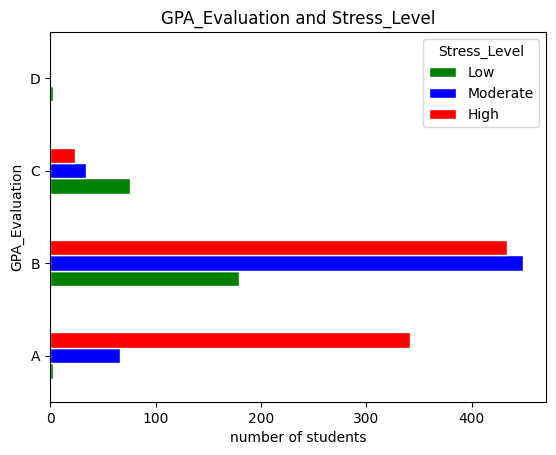

In [160]:
import matplotlib.pyplot as plt
df.groupby(['GPA_Evaluation','Stress_Level']).size().unstack().plot(kind='barh', color=['green', 'blue', 'red'],edgecolor='white')
plt.title('GPA_Evaluation and Stress_Level')
plt.xlabel('number of students')
plt.ylabel
plt.show()

C:\Users\USER PC\AppData\Local\Temp\ipykernel_16488\1362961508.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sleep_class','Stress_Level']).size().unstack().plot(kind='bar', color=['#2ca02c', '#1f77b4', '#d62728'],edgecolor='white')


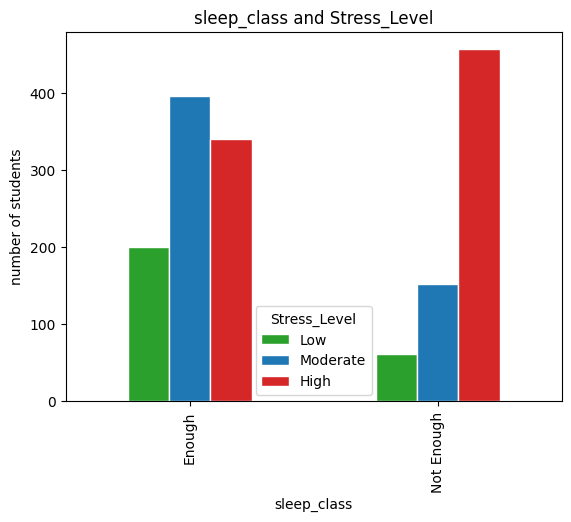

In [167]:
df.groupby(['sleep_class','Stress_Level']).size().unstack().plot(kind='bar', color=['#2ca02c', '#1f77b4', '#d62728'],edgecolor='white')
plt.title('sleep_class and Stress_Level')
plt.xlabel('sleep_class')
plt.ylabel('number of students')
plt.show()

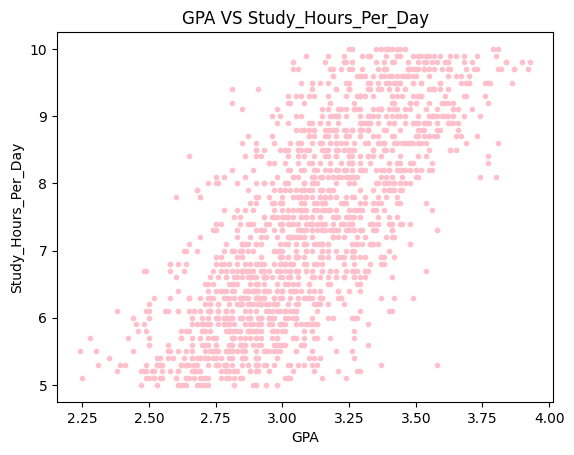

In [182]:
plt.scatter(df['GPA'],df['Study_Hours_Per_Day'],color='pink',marker='.',alpha=1)
plt.title('GPA VS Study_Hours_Per_Day')
plt.xlabel('GPA')
plt.ylabel('Study_Hours_Per_Day')
plt.show()

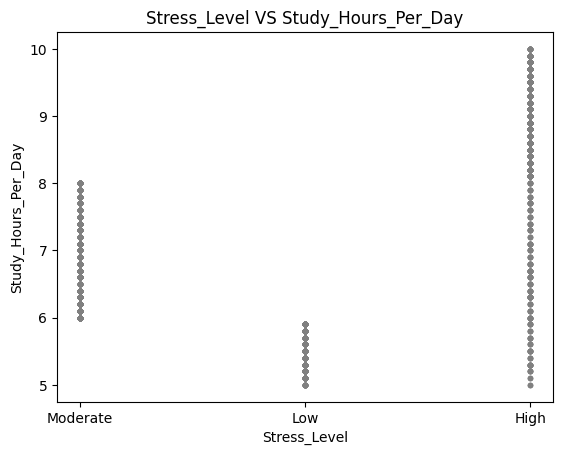

In [122]:
plt.scatter(df['Stress_Level'],df['Study_Hours_Per_Day'],color='gray',marker='.',alpha=1)
plt.title('Stress_Level VS Study_Hours_Per_Day')
plt.xlabel('Stress_Level')
plt.ylabel('Study_Hours_Per_Day')
plt.show()

In [125]:
print(df.loc[df['Study_Hours_Per_Day']<6,'Stress_Level'].value_counts(normalize=True))

Stress_Level
Low         0.80805
High        0.19195
Moderate    0.00000
Name: proportion, dtype: float64


In [128]:
print(df.loc[df['Study_Hours_Per_Day']<6,'sleep_class'].value_counts(normalize=True))

sleep_class
Enough        0.613636
Not Enough    0.386364
Name: proportion, dtype: float64


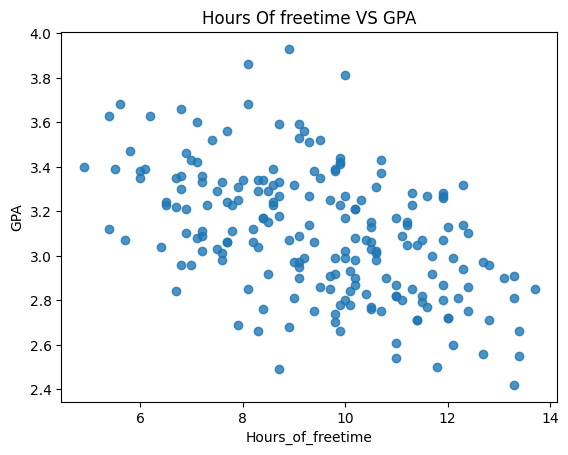

In [146]:
plt.scatter(df['Hours_of_freetime'], df['GPA'], alpha=0.8)
plt.title('Hours Of freetime VS GPA')
plt.xlabel('Hours_of_freetime')
plt.ylabel('GPA')
plt.show()

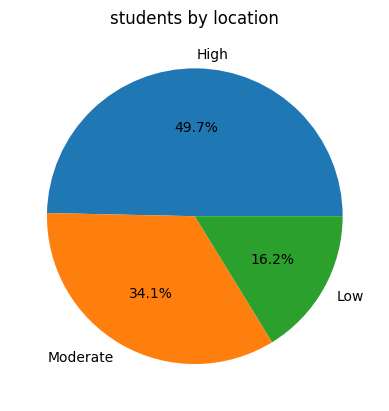

In [183]:
df['Stress_Level'].value_counts().plot.pie(autopct='%1.1f%%',startangle=0)
plt.title('students by location')
plt.ylabel('')#hide default y-label
plt.show()